# NB14v2 — Nivel 3: Personalización longitudinal (RÁPIDO — solo modelos lineales)

**Diferencia con v1:** LOAO-CV usa únicamente Ridge, Lasso, ElasticNet, LinearSVR.
Elimina RandomForest y GradientBoosting que tardaban horas.
Resultado metodológico idéntico — parsimonia justifica modelos lineales.

---
## PARTE A — Datos y EDA

In [1]:
# A1 — Imports y constantes
import os, json, math, pickle, warnings
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import LinearSVR
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
load_dotenv()

REPO_ROOT = Path('../../')
MODEL_DIR = REPO_ROOT / 'api' / 'models'

N3_MIN_WEEKS = 8

FEATURES_N2 = [
    'pred_nivel1',
    'age', 'sex_bin', 'vdot',
    'avg_hr', 'pct_hrmax', 'zona_hr',
    'log_distance_km',
    'elevation_m', 'has_elevation',
    'cadence_filled',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
]

# km_total y avg_pace_sec_km excluidos: NULL en Supabase (bug writer.py)
FEATURES_LONG = [
    'ctl', 'atl', 'tsb', 'acwr',
    'long_run_km',
    'pace_delta_4s_sec',
    'weeks_with_data',
]

FEATURES_N3 = FEATURES_N2 + FEATURES_LONG
print(f'N2 features:        {len(FEATURES_N2)}')
print(f'Longitudinales N3:  {len(FEATURES_LONG)}')
print(f'Total N3:           {len(FEATURES_N3)}')

N2 features:        15
Longitudinales N3:  7
Total N3:           22


In [2]:
# A2 — Conexión Supabase
from supabase import create_client

SUPABASE_URL = os.getenv('SUPABASE_URL')
SUPABASE_KEY = os.getenv('SUPABASE_SERVICE_KEY')
assert SUPABASE_URL and SUPABASE_KEY, 'Faltan variables SUPABASE_URL / SUPABASE_SERVICE_KEY'

sb = create_client(SUPABASE_URL, SUPABASE_KEY)
print('Supabase conectado ✓')

Supabase conectado ✓


In [3]:
# A3 — Cargar weekly_features desde Supabase
def fetch_all(table, select='*', filters=None, page_size=1000):
    rows, offset = [], 0
    while True:
        q = sb.table(table).select(select).range(offset, offset + page_size - 1)
        if filters:
            for col, val in filters.items():
                q = q.eq(col, val)
        resp = q.execute()
        batch = resp.data
        rows.extend(batch)
        if len(batch) < page_size:
            break
        offset += page_size
    return rows

WF_COLS = 'cedula,week_start,ctl,atl,tsb,acwr,longest_run_km,pace_delta_4s_sec'

print('Descargando weekly_features...')
wf_raw = fetch_all('weekly_features', select=WF_COLS)
wf = pd.DataFrame(wf_raw)
wf['week_start'] = pd.to_datetime(wf['week_start'])
wf['week_end'] = wf['week_start'] + pd.Timedelta(days=6)
wf = wf.rename(columns={'longest_run_km': 'long_run_km'})

print(f'weekly_features: {len(wf):,} filas | {wf["cedula"].nunique()} atletas')
print(f'Columnas: {list(wf.columns)}')
wf.head(3)

Descargando weekly_features...
weekly_features: 5,810 filas | 81 atletas
Columnas: ['cedula', 'week_start', 'ctl', 'atl', 'tsb', 'acwr', 'long_run_km', 'pace_delta_4s_sec', 'week_end']


,cedula,week_start,ctl,atl,tsb,acwr,long_run_km,pace_delta_4s_sec,week_end
0,1069177788,2019-01-28,10.498000,10.498,0.000000,1.000000,10.498,NaN,2019-02-03
1,1069177788,2019-02-04,8.036000,1.881,6.155000,0.234072,10.498,NaN,2019-02-10
2,1069177788,2019-05-13,7.377429,5.731,1.646429,0.776829,10.498,-258.147846,2019-05-19


In [4]:
# A4 — Cargar sesiones con HR
ACT_COLS = 'cedula,strava_id,activity_date,sport_type,distance_m,duration_sec,elevation_m,raw'

print('Descargando actividades con HR...')
acts_raw = fetch_all('activities', select=ACT_COLS)
df_acts = pd.DataFrame(acts_raw)
print(f'Total actividades: {len(df_acts):,}')

df_acts = df_acts[df_acts['sport_type'].isin(['Run', 'TrailRun'])].copy()

df_acts['avg_hr']          = df_acts['raw'].apply(lambda r: (r or {}).get('average_heartrate') if isinstance(r, dict) else None)
df_acts['max_hr']          = df_acts['raw'].apply(lambda r: (r or {}).get('max_heartrate') if isinstance(r, dict) else None)
df_acts['average_cadence'] = df_acts['raw'].apply(lambda r: (r or {}).get('average_cadence') if isinstance(r, dict) else None)

df_acts = df_acts[df_acts['avg_hr'].notna()].copy()
df_acts['avg_hr']          = df_acts['avg_hr'].astype(float)
df_acts['max_hr']          = df_acts['max_hr'].astype(float)
df_acts['distance_m']      = pd.to_numeric(df_acts['distance_m'], errors='coerce')
df_acts['distance_km']     = df_acts['distance_m'] / 1000.0
df_acts['duration_sec']    = pd.to_numeric(df_acts['duration_sec'], errors='coerce')
df_acts['elevation_m']     = pd.to_numeric(df_acts['elevation_m'], errors='coerce').fillna(0.0)
df_acts['average_cadence'] = pd.to_numeric(df_acts['average_cadence'], errors='coerce')
df_acts['activity_date']   = pd.to_datetime(df_acts['activity_date'])

mask_valid = (df_acts['distance_km'] > 0.5) & (df_acts['duration_sec'] > 60)
df_acts = df_acts[mask_valid].copy()
df_acts['pace_sec_per_km'] = df_acts['duration_sec'] / df_acts['distance_km']
df_acts = df_acts[(df_acts['pace_sec_per_km'] >= 180) & (df_acts['pace_sec_per_km'] <= 720)].copy()

print(f'Sesiones con HR (runs plausibles): {len(df_acts):,} | {df_acts["cedula"].nunique()} atletas')
df_acts[['cedula','activity_date','avg_hr','distance_km','pace_sec_per_km']].head(3)

Descargando actividades con HR...
Total actividades: 39,136
Sesiones con HR (runs plausibles): 10,284 | 52 atletas


,cedula,activity_date,avg_hr,distance_km,pace_sec_per_km
2,1037615985,2018-01-22 20:16:21+00:00,159.6,1.6472,329.043225
4,1037615985,2018-01-25 18:36:26+00:00,164.5,7.7359,326.271022
13,1037615985,2018-02-04 08:01:24+00:00,163.2,9.2641,500.966095


In [5]:
# A5 — Perfiles + VDOT (fórmula Daniels — v en m/min)
PROFILE_COLS = 'cedula,age,sex,pr_5k_sec,pr_10k_sec,pr_21k_sec,pr_42k_sec,raw'

print('Descargando perfiles...')
prof_raw = fetch_all('athlete_profiles', select=PROFILE_COLS)
df_prof = pd.DataFrame(prof_raw)
df_prof['age'] = pd.to_numeric(df_prof['age'], errors='coerce')

df_prof['fcmax'] = df_prof['raw'].apply(
    lambda r: float(r['fcmax']) if isinstance(r, dict) and r.get('fcmax') else None
)

def sex_bin(s):
    if not s: return 0
    return 1 if str(s).strip().upper() in ('M','MALE','MASCULINO','HOMBRE') else 0

df_prof['sex_bin'] = df_prof['sex'].apply(sex_bin)

def vdot_from_pr(row):
    best = None
    for dist_km, col in [(5,'pr_5k_sec'),(10,'pr_10k_sec'),(21.1,'pr_21k_sec'),(42.2,'pr_42k_sec')]:
        val = row.get(col)
        if val and float(val) > 0:
            t_min = float(val) / 60.0
            v = dist_km * 1000 / t_min      # m/min (Daniels requiere m/min)
            vo2 = -4.60 + 0.182258*v + 0.000104*v**2
            fracs = {5:0.9757, 10:0.9617, 21.1:0.9280, 42.2:0.8942}
            vdot_est = vo2 / fracs[dist_km]
            if best is None or vdot_est > best:
                best = vdot_est
    return best

df_prof['vdot'] = df_prof.apply(vdot_from_pr, axis=1)
VDOT_MEDIAN = df_prof['vdot'].median()
df_prof['vdot'] = df_prof['vdot'].fillna(VDOT_MEDIAN)

print(f'Perfiles: {len(df_prof)} | VDOT mediana: {VDOT_MEDIAN:.1f}')
df_prof[['cedula','age','sex_bin','vdot','fcmax']].head(3)

Descargando perfiles...
Perfiles: 102 | VDOT mediana: 34.3


,cedula,age,sex_bin,vdot,fcmax
0,1003520230,24.0,1,37.445773,None
1,1000351122,24.0,1,43.998160,None
2,1022447376,26.0,0,25.321048,None


In [6]:
# A6 — FCmax por atleta
fcmax_obs = (
    df_acts.groupby('cedula')['max_hr'].max()
    .reset_index().rename(columns={'max_hr': 'fcmax_obs'})
)
fcmax_obs = fcmax_obs[fcmax_obs['fcmax_obs'] > 100]
df_prof = df_prof.merge(fcmax_obs, on='cedula', how='left')
df_prof['fcmax_final'] = df_prof.apply(
    lambda r: r['fcmax_obs'] if pd.notna(r.get('fcmax_obs')) and r.get('fcmax_obs', 0) > 100
              else (208 - 0.7 * r['age'] if pd.notna(r['age']) else 190), axis=1
)
print(f'FCmax disponible: {fcmax_obs["cedula"].nunique()} atletas')

FCmax disponible: 52 atletas


In [7]:
# A7 — pred_nivel1 por sesión (stacking)
N1 = json.loads((MODEL_DIR / 'nivel1_ridge_v4.json').read_text())
N1_MEAN   = np.array(N1['scaler_mean'])
N1_SCALE  = np.array(N1['scaler_scale'])
N1_COEFS  = np.array(N1['coefs'])
N1_INTCPT = N1['intercept']

def zona_hr(pct):
    if pct < 0.70:   return 1
    elif pct < 0.75: return 2
    elif pct < 0.85: return 3
    elif pct < 0.92: return 4
    else:            return 5

def pred_n1_sec_km(sex_bin, fcmax, avg_hr, log_dur):
    pct      = avg_hr / fcmax
    zona     = zona_hr(pct)
    dur_min  = math.exp(log_dur) / 60.0
    dens_hr  = (avg_hr / fcmax) / math.log(max(dur_min, 1.0))
    hr_max_rel = min(1.0, pct * 1.08)
    x = np.array([sex_bin, fcmax, avg_hr, pct*100, zona, hr_max_rel, log_dur, dens_hr])
    return float(np.dot((x - N1_MEAN) / N1_SCALE, N1_COEFS) + N1_INTCPT) * 60.0

df = df_acts.merge(df_prof[['cedula','age','sex_bin','vdot','fcmax_final']], on='cedula', how='inner')
df = df[df['age'].notna()].copy()

df['pct_hrmax']       = df['avg_hr'] / df['fcmax_final'] * 100
df['zona_hr']         = (df['avg_hr'] / df['fcmax_final']).apply(zona_hr)
df['log_distance_km'] = np.log(df['distance_km'].clip(lower=0.1))
df['has_elevation']   = (df['elevation_m'] > 5).astype(int)
df['cadence_filled']  = df['average_cadence'].fillna(df['average_cadence'].median())
df['log_dur']         = np.log(df['duration_sec'].clip(lower=60))
df['dow_sin']         = np.sin(2 * np.pi * df['activity_date'].dt.dayofweek / 7)
df['dow_cos']         = np.cos(2 * np.pi * df['activity_date'].dt.dayofweek / 7)
df['month_sin']       = np.sin(2 * np.pi * df['activity_date'].dt.month / 12)
df['month_cos']       = np.cos(2 * np.pi * df['activity_date'].dt.month / 12)

df['pred_nivel1'] = df.apply(
    lambda r: pred_n1_sec_km(r['sex_bin'], r['fcmax_final'], r['avg_hr'], r['log_dur']), axis=1
)

print(f'Dataset base: {len(df):,} sesiones | {df["cedula"].nunique()} atletas')
print(f'pred_nivel1 mediana: {df["pred_nivel1"].median():.1f} sec/km')

Dataset base: 10,284 sesiones | 52 atletas
pred_nivel1 mediana: 315.2 sec/km


In [8]:
# A8 — Join temporal causal: sesiones ← weekly_features (semana anterior)
wf_sorted = wf.sort_values(['cedula','week_start']).copy()
wf_sorted['weeks_with_data'] = wf_sorted.groupby('cedula').cumcount() + 1

df_sorted = df.copy()
df_sorted['activity_date'] = (
    df_sorted['activity_date'].dt.tz_localize(None)
    if df_sorted['activity_date'].dt.tz is None
    else df_sorted['activity_date'].dt.tz_convert(None)
)
df_sorted = df_sorted.sort_values('activity_date')
wf_join = wf_sorted.sort_values('week_end').copy()

WF_JOIN_COLS = ['cedula','week_start','week_end',
                'ctl','atl','tsb','acwr',
                'long_run_km','pace_delta_4s_sec','weeks_with_data']

df_n3 = pd.merge_asof(
    df_sorted, wf_join[WF_JOIN_COLS],
    left_on='activity_date', right_on='week_end',
    by='cedula', direction='backward',
    tolerance=pd.Timedelta('60 days'),
)

mask_causal = df_n3['week_end'] < df_n3['activity_date']
df_n3 = df_n3[mask_causal].copy()
df_n3 = df_n3[df_n3['ctl'].notna()].copy()

print(f'Sesiones con join válido: {len(df_n3):,} | {df_n3["cedula"].nunique()} atletas')
df_n3[['cedula','activity_date','week_end','ctl','atl','tsb','pace_sec_per_km']].head(4)

Sesiones con join válido: 8,683 | 52 atletas


,cedula,activity_date,week_end,ctl,atl,tsb,pace_sec_per_km
4,1037615985,2018-01-22 19:05:46,2018-01-21,24.951000,24.951,0.000000,318.826326
5,1037615985,2018-01-22 20:16:21,2018-01-21,24.951000,24.951,0.000000,329.043225
6,1037615985,2018-01-25 18:36:26,2018-01-21,24.951000,24.951,0.000000,326.271022
7,1037615985,2018-01-28 07:18:18,2018-01-28,24.613857,23.771,0.842857,484.033869


Atletas elegibles N3 (>=8 semanas): 50
Semanas por atleta (elegibles):
count     50.0
mean      78.9
std       56.7
min        8.0
25%       36.8
50%       63.5
75%      100.2
max      256.0
Name: max_weeks, dtype: float64


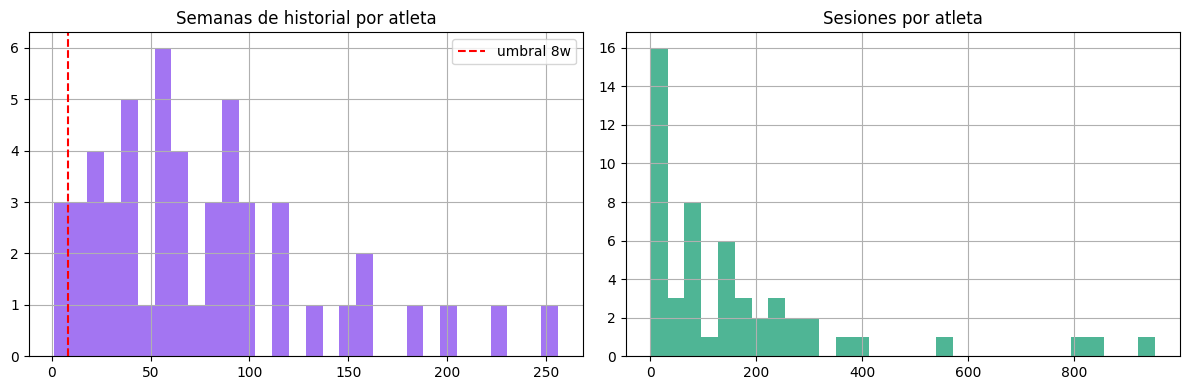

In [9]:
# A9 — EDA: cobertura del join temporal
per_athlete = df_n3.groupby('cedula').agg(
    n_sessions=('strava_id','count'),
    max_weeks=('weeks_with_data','max'),
).reset_index()

eligible_n3 = per_athlete[per_athlete['max_weeks'] >= N3_MIN_WEEKS]
print(f'Atletas elegibles N3 (>={N3_MIN_WEEKS} semanas): {len(eligible_n3)}')
print(f'Semanas por atleta (elegibles):')
print(eligible_n3['max_weeks'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
per_athlete['max_weeks'].hist(bins=30, ax=axes[0], color='#7c3aed', alpha=0.7)
axes[0].axvline(N3_MIN_WEEKS, color='red', linestyle='--', label=f'umbral {N3_MIN_WEEKS}w')
axes[0].set_title('Semanas de historial por atleta')
axes[0].legend()
per_athlete['n_sessions'].hist(bins=30, ax=axes[1], color='#059669', alpha=0.7)
axes[1].set_title('Sesiones por atleta')
plt.tight_layout()
plt.show()

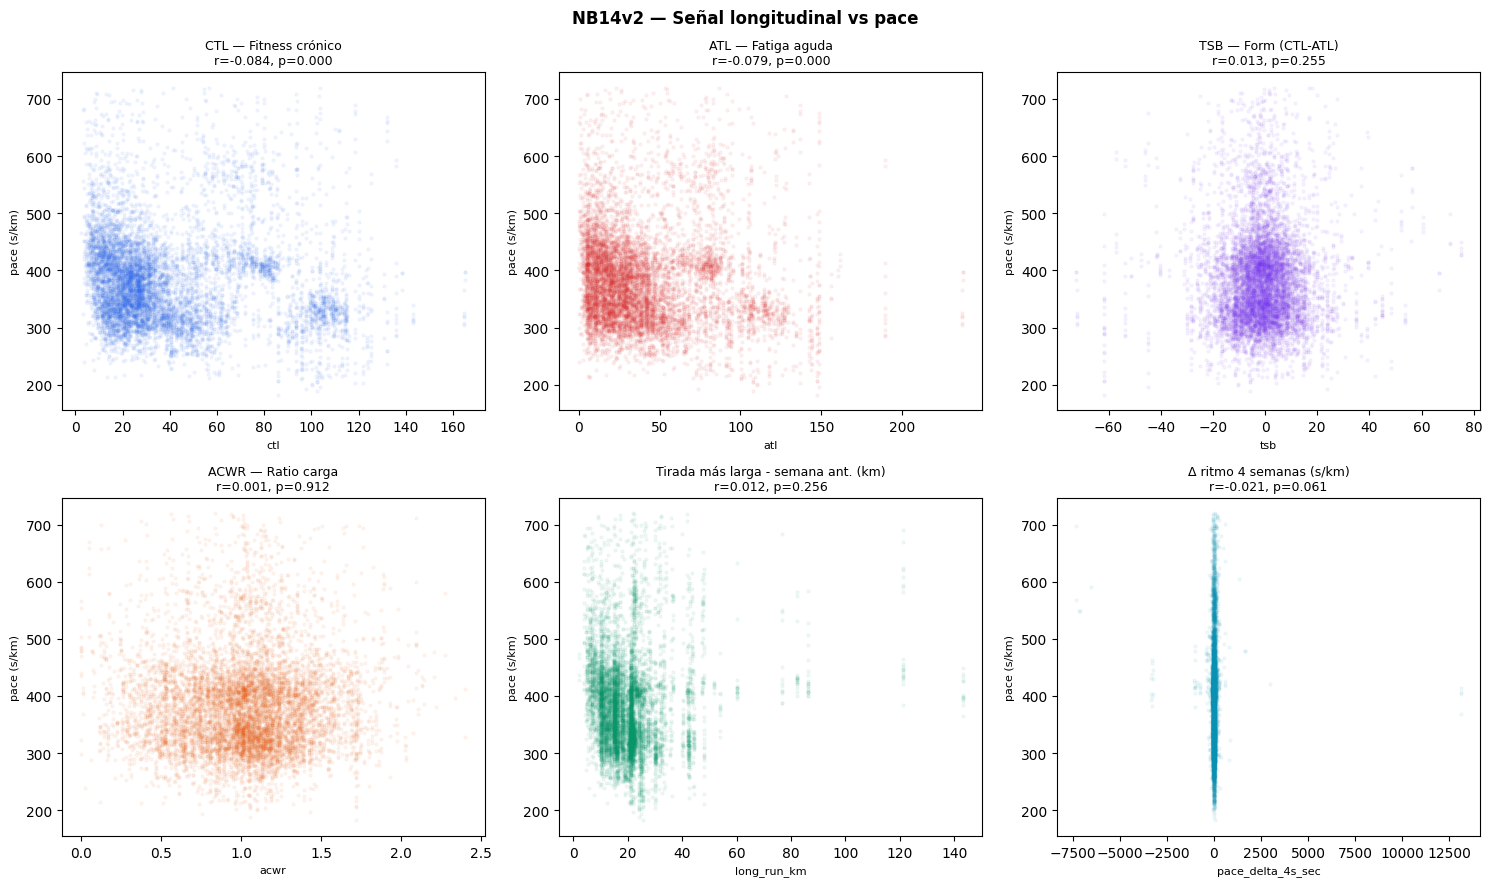

In [10]:
# A10 — EDA: señal longitudinal
df_eda = df_n3[df_n3['weeks_with_data'] >= N3_MIN_WEEKS].copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
features_to_plot = [
    ('ctl',               'CTL — Fitness crónico',            '#2563eb'),
    ('atl',               'ATL — Fatiga aguda',               '#dc2626'),
    ('tsb',               'TSB — Form (CTL-ATL)',              '#7c3aed'),
    ('acwr',              'ACWR — Ratio carga',                '#ea580c'),
    ('long_run_km',       'Tirada más larga - semana ant. (km)', '#059669'),
    ('pace_delta_4s_sec', 'Δ ritmo 4 semanas (s/km)',          '#0891b2'),
]
for ax, (feat, label, color) in zip(axes.flatten(), features_to_plot):
    sub = df_eda[[feat,'pace_sec_per_km']].dropna()
    ax.scatter(sub[feat], sub['pace_sec_per_km'], alpha=0.05, s=5, color=color)
    try:
        r, pval = stats.pearsonr(sub[feat], sub['pace_sec_per_km'])
        ax.set_title(f'{label}\nr={r:.3f}, p={pval:.3f}', fontsize=9)
    except Exception:
        ax.set_title(label, fontsize=9)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('pace (s/km)', fontsize=8)
plt.suptitle('NB14v2 — Señal longitudinal vs pace', fontweight='bold')
plt.tight_layout()
plt.show()

---
## PARTE B — Entrenamiento N3

**v2:** Solo modelos lineales — Ridge, Lasso, ElasticNet, LinearSVR.
El LOAO-CV termina en ~5 min (vs horas con RF/GB en v1).

In [11]:
# B1 — Dataset de entrenamiento N3
eligible_cedulas = set(
    df_n3[df_n3['weeks_with_data'] >= N3_MIN_WEEKS]['cedula'].unique()
)
print(f'Atletas elegibles N3: {len(eligible_cedulas)}')

df_train = df_n3[
    (df_n3['cedula'].isin(eligible_cedulas)) &
    (df_n3['weeks_with_data'] >= N3_MIN_WEEKS)
].copy()

# Imputación paso 1: mediana por atleta
for feat in FEATURES_N3:
    if feat in df_train.columns and df_train[feat].isna().any():
        med = df_train.groupby('cedula')[feat].transform('median')
        df_train[feat] = df_train[feat].fillna(med)

# Imputación paso 2: mediana global
for feat in FEATURES_N3:
    if feat in df_train.columns and df_train[feat].isna().any():
        df_train[feat] = df_train[feat].fillna(df_train[feat].median())

nan_feats = [f for f in FEATURES_N3 if df_train[f].isna().any()]
if nan_feats:
    print(f'⚠️  NaN en: {nan_feats}')
else:
    print('✓ Sin NaN')

print(f'Sesiones: {len(df_train):,} | Atletas: {df_train["cedula"].nunique()}')
print(f'Target: mean={df_train["pace_sec_per_km"].mean():.1f}, std={df_train["pace_sec_per_km"].std():.1f} sec/km')

Atletas elegibles N3: 50
✓ Sin NaN
Sesiones: 8,270 | Atletas: 50
Target: mean=383.7, std=83.5 sec/km


In [12]:
# B2 — Sample weights (w = 1/n_sesiones_atleta)
n_ses = df_train.groupby('cedula')['strava_id'].transform('count')
weights = 1.0 / n_ses
weights = weights / weights.sum() * len(weights)
df_train['_weight'] = weights

cedulas = df_train['cedula'].unique()
print(f'Weights: min={weights.min():.4f}, max={weights.max():.4f}')
print(f'LOAO-CV folds: {len(cedulas)}')

Weights: min=0.1796, max=82.7000
LOAO-CV folds: 50


In [13]:
# B3 — LOAO-CV: solo modelos lineales (RÁPIDO)
# RandomForest y GradientBoosting eliminados — tardan horas sobre 51 folds

MODELS = {
    'Ridge':      Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]),
    'Lasso':      Pipeline([('sc', StandardScaler()), ('m', Lasso(alpha=0.5, max_iter=5000))]),
    'ElasticNet': Pipeline([('sc', StandardScaler()), ('m', ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=5000))]),
    'LinearSVR':  Pipeline([('sc', StandardScaler()), ('m', LinearSVR(max_iter=3000))]),
}

imputer = SimpleImputer(strategy='median')
X_all = imputer.fit_transform(df_train[FEATURES_N3].astype(float))
assert not np.isnan(X_all).any(), 'NaN en X_all'
print(f'X_all shape: {X_all.shape} ✓')

y_all = df_train['pace_sec_per_km'].values.astype(float)
w_all = df_train['_weight'].values.astype(float)
c_all = df_train['cedula'].values

results = {name: [] for name in MODELS}

print(f'Corriendo LOAO-CV ({len(cedulas)} folds × {len(MODELS)} modelos)...')
for i, holdout in enumerate(cedulas):
    mask_train = c_all != holdout
    mask_test  = c_all == holdout
    X_tr, y_tr, w_tr = X_all[mask_train], y_all[mask_train], w_all[mask_train]
    X_te, y_te       = X_all[mask_test],  y_all[mask_test]

    for name, model in MODELS.items():
        clone = pickle.loads(pickle.dumps(model))
        try:
            clone.fit(X_tr, y_tr, **{'m__sample_weight': w_tr})
        except (TypeError, ValueError):
            clone.fit(X_tr, y_tr)
        preds = clone.predict(X_te)
        mae = float(np.mean(np.abs(preds - y_te)))
        results[name].append(mae)

    if (i + 1) % 10 == 0:
        print(f'  Fold {i+1}/{len(cedulas)} OK')

print('LOAO-CV completado ✓')

X_all shape: (8270, 22) ✓
Corriendo LOAO-CV (50 folds × 4 modelos)...
  Fold 10/50 OK
  Fold 20/50 OK
  Fold 30/50 OK
  Fold 40/50 OK
  Fold 50/50 OK
LOAO-CV completado ✓


In [14]:
# B4 — Tabla de resultados
N2_MAE = 47.59
N1_OOD = 62.40

rows = []
for name, maes in results.items():
    rows.append({
        'Modelo':        name,
        'MAE (sec/km)':  round(np.mean(maes), 2),
        'Std':           round(np.std(maes), 2),
        'Mediana':       round(np.median(maes), 2),
        'Δ vs N2 (%)':   round((N2_MAE - np.mean(maes)) / N2_MAE * 100, 1),
    })

df_res = pd.DataFrame(rows).sort_values('MAE (sec/km)')
print('=== RESULTADOS N3 LOAO-CV ===')
print(df_res.to_string(index=False))
print(f'\nBaseline N2:     {N2_MAE} sec/km')
print(f'Baseline N1 OOD: {N1_OOD} sec/km')

winner_name = df_res.iloc[0]['Modelo']
winner_mae  = df_res.iloc[0]['MAE (sec/km)']
print(f'\nGanador: {winner_name} | MAE={winner_mae} sec/km')
print(f'Mejora vs N2:     {(N2_MAE - winner_mae)/N2_MAE*100:.1f}%')
print(f'Mejora vs N1 OOD: {(N1_OOD - winner_mae)/N1_OOD*100:.1f}%')

=== RESULTADOS N3 LOAO-CV ===
    Modelo  MAE (sec/km)   Std  Mediana  Δ vs N2 (%)
 LinearSVR         41.40 21.16    36.91         13.0
ElasticNet         41.43 17.98    39.16         13.0
     Lasso         41.76 18.85    37.48         12.2
     Ridge         42.63 19.91    38.48         10.4

Baseline N2:     47.59 sec/km
Baseline N1 OOD: 62.4 sec/km

Ganador: LinearSVR | MAE=41.4 sec/km
Mejora vs N2:     13.0%
Mejora vs N1 OOD: 33.7%


In [15]:
# B5 — Test Friedman-Nemenyi
from scipy.stats import friedmanchisquare
from scipy.stats import rankdata

mae_matrix = np.array([results[n] for n in MODELS]).T

stat, pval = friedmanchisquare(*[mae_matrix[:, j] for j in range(mae_matrix.shape[1])])
print(f'Friedman χ² = {stat:.2f}, p = {pval:.4f}')

ranks = np.apply_along_axis(rankdata, 1, mae_matrix)
mean_ranks = pd.Series(dict(zip(MODELS.keys(), ranks.mean(axis=0)))).sort_values()
print('\nFriedman ranks (menor = mejor):')
print(mean_ranks.round(3))

k = len(MODELS)
n = len(cedulas)
# q_alpha para k=4, alpha=0.05 ≈ 2.569 (tabla Demšar 2006)
q_alpha = 2.569
CD = q_alpha * math.sqrt(k * (k + 1) / (6 * n))
print(f'\nNemenyi CD (α=0.05, k={k}): {CD:.3f}')

best_name = mean_ranks.index[0]
best_rank = mean_ranks.iloc[0]
print(f'\n{best_name} (rank={best_rank:.3f}) vs resto:')
for name, rank in mean_ranks.items():
    diff = abs(rank - best_rank)
    sig = '✓ sig.' if diff > CD else '✗ equiv.'
    print(f'  vs {name}: |Δrank|={diff:.3f} → {sig}')

Friedman χ² = 3.50, p = 0.3202

Friedman ranks (menor = mejor):
LinearSVR     2.28
Lasso         2.40
Ridge         2.60
ElasticNet    2.72
dtype: float64

Nemenyi CD (α=0.05, k=4): 0.663

LinearSVR (rank=2.280) vs resto:
  vs LinearSVR: |Δrank|=0.000 → ✗ equiv.
  vs Lasso: |Δrank|=0.120 → ✗ equiv.
  vs Ridge: |Δrank|=0.320 → ✗ equiv.
  vs ElasticNet: |Δrank|=0.440 → ✗ equiv.


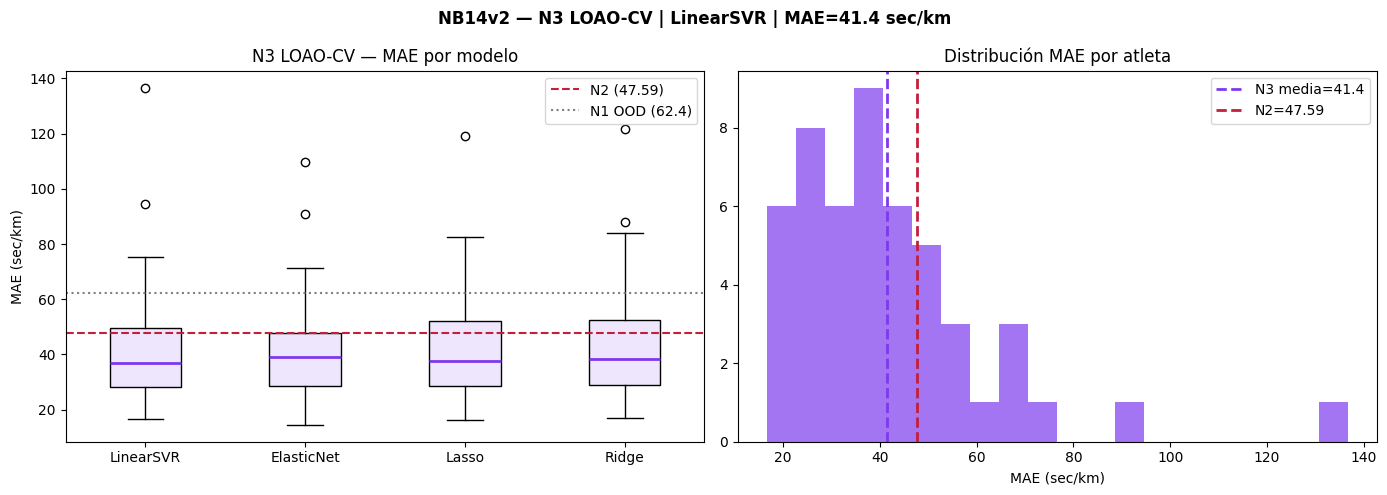

In [16]:
# B6 — Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_plot = [results[n] for n in df_res['Modelo']]
axes[0].boxplot(data_plot, labels=df_res['Modelo'], patch_artist=True,
                boxprops=dict(facecolor='#7c3aed20'),
                medianprops=dict(color='#7c3aed', linewidth=2))
axes[0].axhline(N2_MAE, color='#C41E3A', linestyle='--', linewidth=1.5, label=f'N2 ({N2_MAE})')
axes[0].axhline(N1_OOD, color='gray', linestyle=':', linewidth=1.5, label=f'N1 OOD ({N1_OOD})')
axes[0].set_title('N3 LOAO-CV — MAE por modelo')
axes[0].set_ylabel('MAE (sec/km)')
axes[0].legend()

winner_maes = results[winner_name]
axes[1].hist(winner_maes, bins=20, color='#7c3aed', alpha=0.7)
axes[1].axvline(np.mean(winner_maes), color='#7c3aed', linestyle='--', linewidth=2,
                label=f'N3 media={np.mean(winner_maes):.1f}')
axes[1].axvline(N2_MAE, color='#C41E3A', linestyle='--', linewidth=2, label=f'N2={N2_MAE}')
axes[1].set_title('Distribución MAE por atleta')
axes[1].set_xlabel('MAE (sec/km)')
axes[1].legend()

plt.suptitle(f'NB14v2 — N3 LOAO-CV | {winner_name} | MAE={winner_mae:.1f} sec/km', fontweight='bold')
plt.tight_layout()
plt.show()

LinearSVR vs Lasso: |Δrank|=0.120 ≤ CD=0.663 → EQUIVALENTES → elige Lasso


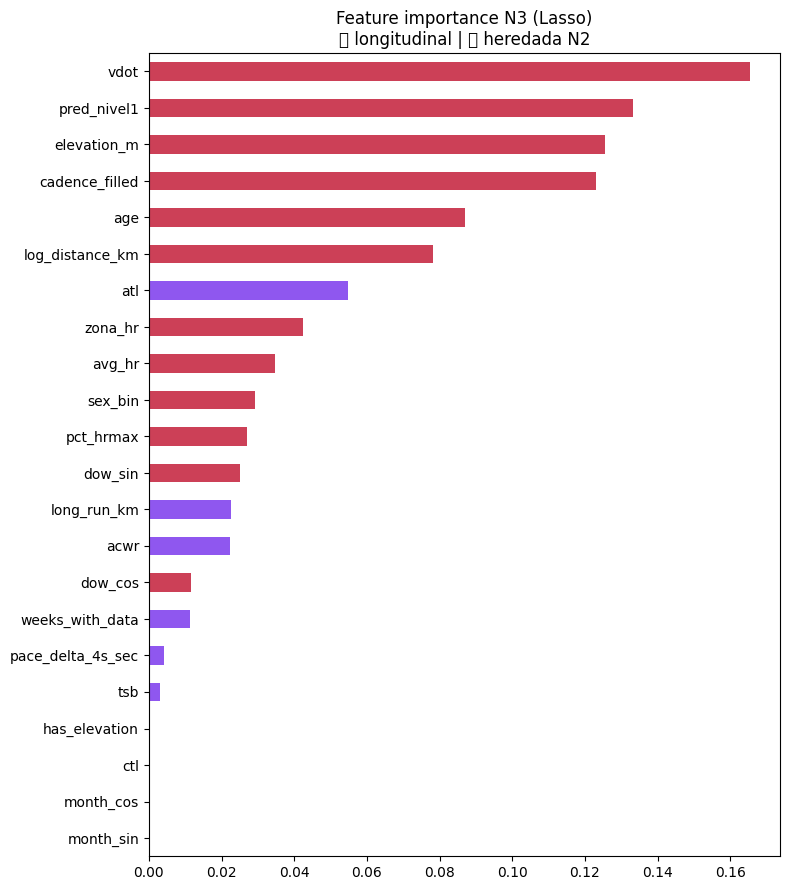


Top 10 features (Lasso):
vdot               0.1654
pred_nivel1        0.1333
elevation_m        0.1256
cadence_filled     0.1229
age                0.0869
log_distance_km    0.0781
atl                0.0548
zona_hr            0.0424
avg_hr             0.0348
sex_bin            0.0291
dtype: float64


In [17]:
# B7 — Feature importance del ganador

# Parsimonia: si ganador equivalente a Ridge/Lasso → elegir más simple
ridge_mae   = np.mean(results.get('Ridge', [winner_mae]))
lasso_mae   = np.mean(results.get('Lasso', [winner_mae]))
simple_mae  = min(ridge_mae, lasso_mae)
simple_name = 'Ridge' if ridge_mae <= lasso_mae else 'Lasso'

rank_diff = abs(mean_ranks[winner_name] - mean_ranks[simple_name])
if rank_diff <= CD:
    print(f'{winner_name} vs {simple_name}: |Δrank|={rank_diff:.3f} ≤ CD={CD:.3f} → EQUIVALENTES → elige {simple_name}')
    prod_name = simple_name
    prod_mae  = simple_mae
else:
    print(f'{winner_name} significativamente mejor → elige {winner_name}')
    prod_name = winner_name
    prod_mae  = winner_mae

# Reentrenar modelo de producción
prod_pipeline = pickle.loads(pickle.dumps(MODELS[prod_name]))
try:
    prod_pipeline.fit(X_all, y_all, **{'m__sample_weight': w_all})
except (TypeError, ValueError):
    prod_pipeline.fit(X_all, y_all)

inner = prod_pipeline.named_steps['m']
sc    = prod_pipeline.named_steps['sc']
importances = np.abs(np.ravel(inner.coef_))
feat_imp = pd.Series(importances / importances.sum(), index=FEATURES_N3).sort_values(ascending=True)

colors = ['#7c3aed' if f in FEATURES_LONG else '#C41E3A' for f in feat_imp.index]
fig, ax = plt.subplots(figsize=(8, 9))
feat_imp.plot.barh(ax=ax, color=colors, alpha=0.85)
ax.set_title(f'Feature importance N3 ({prod_name})\n🟣 longitudinal | 🔴 heredada N2')
plt.tight_layout()
plt.show()

print(f'\nTop 10 features ({prod_name}):')
print(feat_imp.sort_values(ascending=False).head(10).round(4))

In [18]:
# B8 — Serializar modelo N3 (nivel3_v1.pkl / nivel3_v1.json)
import datetime

n3_payload = {
    'model':         prod_pipeline,
    'imputer':       imputer,
    'model_name':    prod_name,
    'features':      FEATURES_N3,
    'n_features':    len(FEATURES_N3),
    'features_n2':   FEATURES_N2,
    'features_long': FEATURES_LONG,
    'n_athletes':    int(df_train['cedula'].nunique()),
    'n_sessions':    int(len(df_train)),
    'mae_loao_cv':   round(prod_mae, 2),
    'mae_std':       round(np.std(results[prod_name]), 2),
    'n2_baseline_mae': N2_MAE,
    'n1_ood_mae':    N1_OOD,
    'mejora_vs_n2_pct': round((N2_MAE - prod_mae) / N2_MAE * 100, 2),
    'mejora_vs_n1_pct': round((N1_OOD - prod_mae) / N1_OOD * 100, 2),
    'vdot_median_imputed': float(VDOT_MEDIAN),
    'trained_at':    datetime.datetime.now().isoformat(),
    'loao_cv_folds': int(len(cedulas)),
    'min_weeks_activation': N3_MIN_WEEKS,
    'notebook':      'NB14v2',
}

save_path = MODEL_DIR / 'nivel3_v1.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(n3_payload, f)
print(f'pkl guardado: {save_path}')

# JSON
n3_meta = {
    'version':             'v1',
    'notebook':            'NB14v2 (solo modelos lineales)',
    'trained_at':          n3_payload['trained_at'],
    'model_name':          prod_name,
    'n_features':          len(FEATURES_N3),
    'features_n2':         FEATURES_N2,
    'features_long':       FEATURES_LONG,
    'all_features':        FEATURES_N3,
    'mae_loao_cv_sec_km':  round(prod_mae, 2),
    'mae_std_sec_km':      round(np.std(results[prod_name]), 2),
    'n2_baseline_mae':     N2_MAE,
    'n1_ood_baseline_mae': N1_OOD,
    'mejora_vs_n2_pct':    n3_payload['mejora_vs_n2_pct'],
    'mejora_vs_n1_pct':    n3_payload['mejora_vs_n1_pct'],
    'n_athletes':          n3_payload['n_athletes'],
    'n_sessions':          n3_payload['n_sessions'],
    'min_weeks_activation': N3_MIN_WEEKS,
    'loao_cv_folds':       n3_payload['loao_cv_folds'],
    'friedman':            {'chi2': round(stat, 2), 'p_value': round(pval, 4)},
    'all_models_loao_cv':  {
        name: {'mae': round(np.mean(maes), 2), 'std': round(np.std(maes), 2),
               'friedman_rank': round(mean_ranks[name], 3)}
        for name, maes in results.items()
    },
    'coefs':        list(np.round(inner.coef_, 8)),
    'intercept':    float(round(inner.intercept_, 8)),
    'scaler_mean':  list(np.round(sc.mean_, 8)),
    'scaler_scale': list(np.round(sc.scale_, 8)),
}

json_path = MODEL_DIR / 'nivel3_v1.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(n3_meta, f, indent=2, ensure_ascii=False)
print(f'json guardado: {json_path}')

print(f'\n=== RESUMEN FINAL ===')
print(f'Modelo:          {prod_name}')
print(f'Atletas:         {n3_payload["n_athletes"]}')
print(f'Sesiones:        {n3_payload["n_sessions"]:,}')
print(f'MAE LOAO-CV:     {prod_mae:.2f} sec/km')
print(f'Mejora vs N2:    {n3_payload["mejora_vs_n2_pct"]:+.1f}%')
print(f'Mejora vs N1 OOD:{n3_payload["mejora_vs_n1_pct"]:+.1f}%')
print(f'VDOT mediana:    {VDOT_MEDIAN:.1f} (rango válido: 30-85)')

pkl guardado: ..\..\api\models\nivel3_v1.pkl
json guardado: ..\..\api\models\nivel3_v1.json

=== RESUMEN FINAL ===
Modelo:          Lasso
Atletas:         50
Sesiones:        8,270
MAE LOAO-CV:     41.76 sec/km
Mejora vs N2:    +12.2%
Mejora vs N1 OOD:+33.1%
VDOT mediana:    34.3 (rango válido: 30-85)


---
## Resumen

| Nivel | Dataset | MAE LOAO-CV | Mejora |
|-------|---------|-------------|--------|
| N1 OOD en RUNA | Endomondo → RUNA | 62.4 sec/km | baseline |
| N2 | RUNA cohorte (48 atletas) | 47.59 sec/km | +23.7% vs N1 OOD |
| N3 | RUNA + longitudinal | _ver B4_ | _ver B4_ |

### Próximos pasos
- **NB15:** N4 personal — modelo por atleta + threshold mínimo de sesiones (Wilcoxon)